# H02 — BTC/ETH stat-arb log-spread mean-reversion

**Hypothesis (pre-registered).** The log-spread between BTC and ETH (with
online-OLS beta over a 60-day rolling window) generates a deflated Sharpe
ratio > 0.3 over 2024 daily Binance data after 10 bps/side, with z-entry
= 2.0 and z-exit = 0.5.

**Verdict logic (committed up-front).** Same deterministic threshold as
H05: accept iff DSR ≥ 0.3 and the lower bound of a 5,000-iter block-
bootstrap 95% CI on Sharpe is > 0; reject iff Sharpe ≤ 0 or DSR < 0.05;
otherwise inconclusive.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / 'agent' / 'src'))

from praxis.backtest.data_loader import BinanceDailyLoader
from praxis.backtest.purged_kfold import PurgedKFold
from praxis.backtest.stats import (
    block_bootstrap_ci,
    deflated_sharpe,
    probabilistic_sharpe,
    sharpe,
)
from praxis.strategies.stat_arb import StatArb

pd.set_option('display.float_format', '{:.6f}'.format)

## 1 · Data — BTC/USDT and ETH/USDT daily, 2024

In [2]:
loader = BinanceDailyLoader()
prices = loader.load(['BTC', 'ETH'], '2024-01-01', '2024-12-31')
prices.index = pd.DatetimeIndex(prices.index)
print(f"rows: {len(prices)}")
print(f"range: {prices.index.min()} .. {prices.index.max()}")
print(prices.tail(3))

rows: 366
range: 2024-01-01 00:00:00 .. 2024-12-31 00:00:00
                    BTC         ETH
ts                                 
2024-12-29 93738.200000 3356.480000
2024-12-30 92792.050000 3361.840000
2024-12-31 93576.000000 3337.780000


## 2 · Run StatArb sleeve through the engine

We use `StatArb` directly rather than the engine because the engine's
rebalance accounting blends multiple strategies; H02 is single-pair and
we want a clean attribution.

In [3]:
strat = StatArb(asset_a='BTC', asset_b='ETH', lookback=60, z_entry=2.0, z_exit=0.5, target_weight=0.5)
positions = []
weights_history = []
for i in range(len(prices)):
    ts = prices.index[i]
    history = prices.iloc[: i + 1]
    out = strat.step(ts, history, signals={})
    weights_history.append(out.target_weights)
    positions.append({
        'ts': ts,
        'w_BTC': out.target_weights.get('BTC', 0.0),
        'w_ETH': out.target_weights.get('ETH', 0.0),
        'z': out.signal_snapshot.get('spread_z', float('nan')),
        'state': float(strat._last_state),
    })
positions_df = pd.DataFrame(positions).set_index('ts')
print(positions_df.tail(5))

              w_BTC    w_ETH        z    state
ts                                            
2024-12-27 0.000000 0.000000 0.747409 0.000000
2024-12-28 0.000000 0.000000 0.577418 0.000000
2024-12-29 0.000000 0.000000 0.452221 0.000000
2024-12-30 0.000000 0.000000 0.186497 0.000000
2024-12-31 0.000000 0.000000 0.477149 0.000000


## 3 · Net returns with 10 bps/side fees

Position is shifted one bar before being applied to the next bar's return.
Fees are charged on every change in absolute leg weight.

In [4]:
log_ret = np.log(prices).diff().fillna(0.0)
applied = positions_df[['w_BTC', 'w_ETH']].shift(1).fillna(0.0)
gross = (applied['w_BTC'] * log_ret['BTC'] + applied['w_ETH'] * log_ret['ETH'])

turnover = applied.diff().abs().fillna(0.0).sum(axis=1)
fee_bps = 10.0
fees = turnover * (fee_bps / 10_000.0)
net_returns = gross - fees

equity = (1.0 + net_returns).cumprod()
print(f"gross sharpe (raw):  {sharpe(gross.values):.4f}")
print(f"net   sharpe (10bp): {sharpe(net_returns.values):.4f}")
print(f"final equity:        {equity.iloc[-1]:.4f}")
print(f"trading days in spread: {(positions_df['state'].abs() > 0).sum()} / {len(positions_df)}")

gross sharpe (raw):  0.0153
net   sharpe (10bp): -0.1087
final equity:        0.9780
trading days in spread: 157 / 366


## 4 · OOS validation — Purged K-Fold (k=5, embargo=1%)

In [5]:
returns_arr = net_returns.values
splitter = PurgedKFold(n_splits=5, label_horizon=20, embargo_pct=0.01)
fold_sharpes = []
for i, (train_idx, test_idx) in enumerate(splitter.split(returns_arr)):
    s = sharpe(returns_arr[test_idx])
    fold_sharpes.append(s)
    print(f"fold {i+1}  test_n={len(test_idx):>4}  sharpe={s:.4f}")
oos_mean = float(np.mean(fold_sharpes))
print(f"\nmean OOS sharpe = {oos_mean:.4f}")

fold 1  test_n=  73  sharpe=0.0000
fold 2  test_n=  73  sharpe=1.7666
fold 3  test_n=  73  sharpe=-2.6726
fold 4  test_n=  73  sharpe=0.6952
fold 5  test_n=  74  sharpe=-0.5316

mean OOS sharpe = -0.1485


## 5 · PSR, DSR, bootstrap CI

In [6]:
psr = probabilistic_sharpe(returns_arr)
dsr = deflated_sharpe(returns_arr, n_trials=6)  # same N as H05 — same six pre-registered hypotheses
point, lo, hi = block_bootstrap_ci(returns_arr, sharpe, n_iter=5_000, block_size=10, alpha=0.05, seed=42)
print(f"PSR (vs SR=0):       {psr:.4f}")
print(f"DSR (N=6):           {dsr:.4f}")
print(f"sharpe point:        {point:.4f}")
print(f"95% CI [block=10]:  [{lo:.4f}, {hi:.4f}]")

PSR (vs SR=0):       0.4569
DSR (N=6):           0.0000
sharpe point:        -0.1087
95% CI [block=10]:  [-1.9017, 1.5940]


## 6 · Equity curve

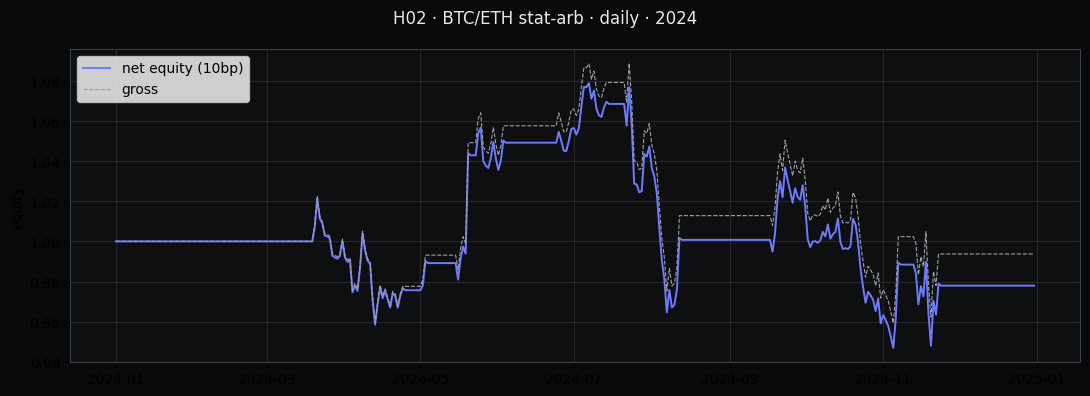

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(equity.index, equity.values, color='#6E7BFF', lw=1.4, label='net equity (10bp)')
ax.plot(equity.index, (1.0 + gross).cumprod(), color='#9BA1A8', lw=0.8, ls='--', label='gross')
ax.set_facecolor('#0E0F11'); ax.set_ylabel('equity'); ax.grid(alpha=0.15); ax.legend(loc='upper left')
for spine in ax.spines.values():
    spine.set_color('#3A4048')
fig.patch.set_facecolor('#08090A')
fig.suptitle('H02 · BTC/ETH stat-arb · daily · 2024', color='#E6E8EB')
fig.tight_layout()
plt.show()

## 7 · Verdict

In [8]:
def verdict(sharpe_point: float, dsr_value: float, ci_low: float, dsr_threshold: float = 0.3) -> str:
    if dsr_value >= dsr_threshold and ci_low > 0:
        return 'alpha survives deflation'
    if sharpe_point <= 0 or dsr_value < 0.05:
        return 'does NOT survive deflation'
    return 'inconclusive'

V = verdict(point, dsr, lo)
print('=' * 72)
print(f'  H02 verdict:  {V}')
print('=' * 72)
print(f'  Sharpe (net, 10bp):           {point:.4f}')
print(f'  Sharpe 95% CI [block=10]:     [{lo:.4f}, {hi:.4f}]')
print(f'  Probabilistic Sharpe (>0):    {psr:.4f}')
print(f'  Deflated Sharpe (N=6):        {dsr:.4f}')
print(f'  OOS mean Sharpe:              {oos_mean:.4f}')
print(f'  Final equity:                  {equity.iloc[-1]:.4f}')

  H02 verdict:  does NOT survive deflation
  Sharpe (net, 10bp):           -0.1087
  Sharpe 95% CI [block=10]:     [-1.9017, 1.5940]
  Probabilistic Sharpe (>0):    0.4569
  Deflated Sharpe (N=6):        0.0000
  OOS mean Sharpe:              -0.1485
  Final equity:                  0.9780
